# Module 03: EDA

In [12]:
# packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [13]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [14]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [15]:
for col in Hitters.columns:
    Hitters.dtypes

### Before doing any other analyses, let's create training and test sets.

In [16]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

In [17]:
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The 6 columns starting with 'C' contain career data and the 6 columns without 'C' represent tyhe single 1986 season. 

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

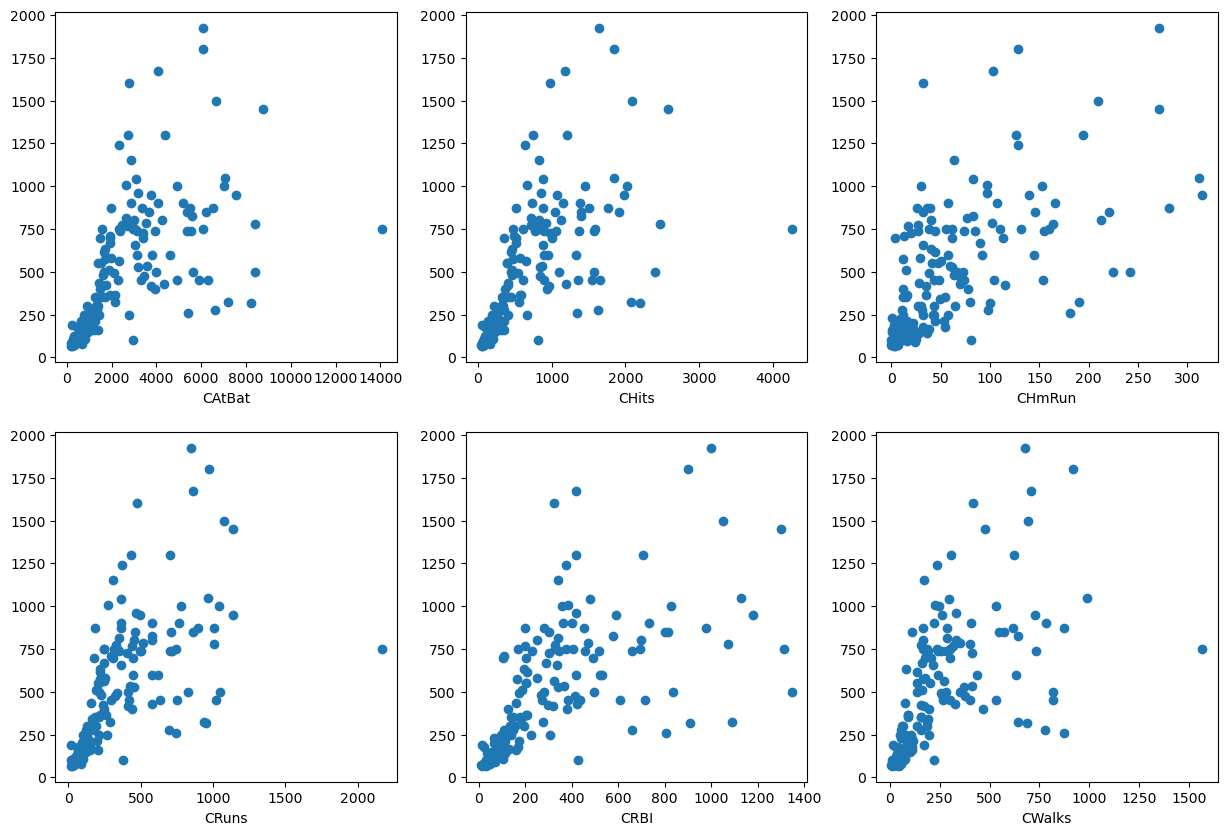

In [18]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [19]:
describe = Hitters.describe()
print(describe)

            AtBat        Hits       HmRun        Runs         RBI       Walks  \
count  322.000000  322.000000  322.000000  322.000000  322.000000  322.000000   
mean   380.928571  101.024845   10.770186   50.909938   48.027950   38.742236   
std    153.404981   46.454741    8.709037   26.024095   26.166895   21.639327   
min     16.000000    1.000000    0.000000    0.000000    0.000000    0.000000   
25%    255.250000   64.000000    4.000000   30.250000   28.000000   22.000000   
50%    379.500000   96.000000    8.000000   48.000000   44.000000   35.000000   
75%    512.000000  137.000000   16.000000   69.000000   64.750000   53.000000   
max    687.000000  238.000000   40.000000  130.000000  121.000000  105.000000   

            Years       CAtBat        CHits      CHmRun        CRuns  \
count  322.000000    322.00000   322.000000  322.000000   322.000000   
mean     7.444099   2648.68323   717.571429   69.490683   358.795031   
std      4.926087   2324.20587   654.472627   86.26606

### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

<Axes: ylabel='Frequency'>

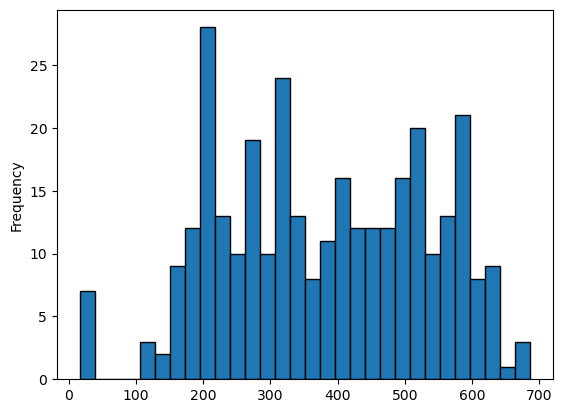

In [20]:
Hitters['AtBat'].plot.hist(bins=30, edgecolor='black')

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [23]:
Train['AtBat_st'] = (Train['AtBat'] - Train['AtBat'].mean()) / Train['AtBat'].std()
print(Train['AtBat_st'])


3      0.783715
63    -1.138317
27     0.632698
130   -0.520521
93     0.886681
         ...   
308    0.673885
90    -0.465605
147    1.490748
232   -0.472470
72     0.893546
Name: AtBat_st, Length: 193, dtype: float64


### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [24]:
print(len(Train['AtBat_st']))

193


### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

I can tell by looking at the count of salary(263) vs the count that I found from the length of the number of rows in the DF. 

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

Missing values would not be reflected in describe() if they are stored as sentinel or placeholder values (such as -999, 999, or strings like "N/A", "Missing", or empty spaces) instead of standard pandas missing values (NaN, None, or pd.NA). Because pandas treats these placeholders as valid data, describe() will include them in the count and factor them into the summary statistics (like mean, min, and max) rather than dropping them.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

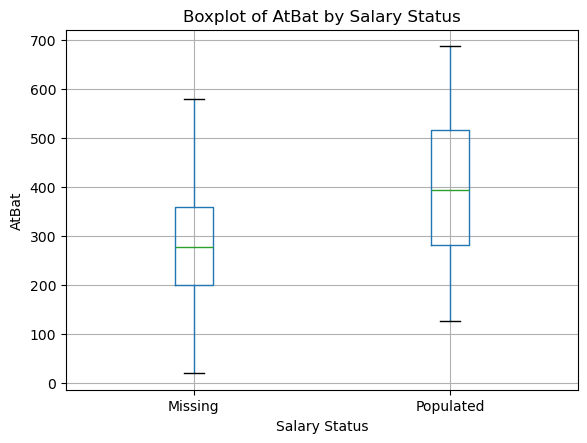

: 

: 

: 

: 

In [ ]:
Train['Salary_Status'] = Train['Salary'].isnull().map(
    {True: 'Missing', False: 'Populated'}
)

Train.boxplot(column='AtBat', by='Salary_Status')

plt.title('Boxplot of AtBat by Salary Status')
plt.suptitle('')
plt.xlabel('Salary Status')
plt.ylabel('AtBat')
plt.show()

### Create a correlation matrix for all numeric features in the training set

In [ ]:

corr_matrix = Train.select_dtypes(include=['number']).corr()


corr_matrix

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170


: 

: 

: 

: 

### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.



* **Regression Imputation:** Train a linear regression model using features strongly correlated with Salary to predict and fill in the missing values.
* **Conditional Group Imputation:** Segment players into performance groups based on variables like AtBat (informed by the boxplot splits) and impute missing values using the median salary of each specific group.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [ ]:
TotHits = Train['Hits'].sum()
TotWalks = Train['Walks'].sum()
TotAtBat = Train['AtBat'].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

: 

: 

: 

: 

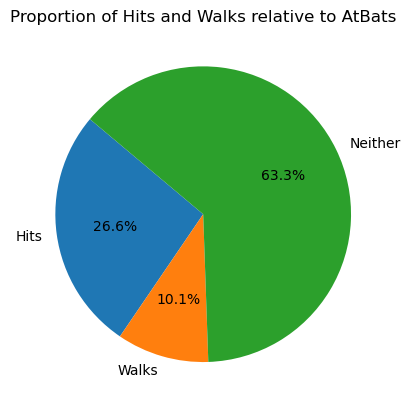

: 

: 

: 

: 

In [ ]:

plt.pie(Totals, labels=Labels, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Hits and Walks relative to AtBats')
plt.show()


### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [ ]:
Train['AVG'] = Train['Hits'] / Train['AtBat']

: 

: 

: 

: 

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [ ]:
Train['AVG_bin'] = 'medium'
Train['AVG_bin'][Train['AVG'] < 0.25] = 'low'
Train['AVG_bin'][Train['AVG'] > 0.31] = 'high'

C:\Users\lundy\AppData\Local\Temp\ipykernel_7260\1013173200.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Train['AVG_bin'][Train['AVG'] < 0.25] = 'low'
C:\Users\lundy\AppData\Local\Temp\ipykernel_7260\1013173200.py:2: SettingWithCopyWa

: 

: 

: 

: 

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [ ]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    114
low        65
high       14
Name: count, dtype: int64

: 

: 

: 

: 

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [ ]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

: 

: 

: 

: 

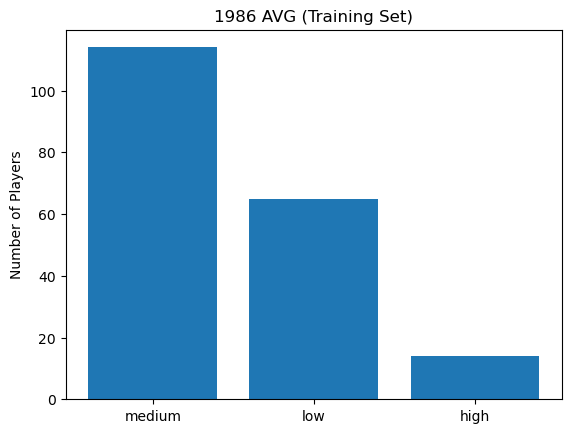

: 

: 

: 

: 

In [ ]:
plt.bar(Train['AVG_bin'].value_counts().index, Train['AVG_bin'].value_counts())

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(Train['AVG_bin'].value_counts().index)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

(Width method). We used fixed numerical threshold values (0.25 and 0.31) along the scale of the variable itself to define the bins, rather than dividing the data into quantiles with an equal number of observations (depth method).